In [1]:
from cache import load_words, load_patterns
from engine import Engine

words = load_words()
patterns = load_patterns()
engine = Engine(words, patterns)

In [2]:
from typing import Dict, List
from tqdm import tqdm

# PNW, anyone?
solutions = [
    'water',
    'climb',
    'rainy',
    'talus',
    'coast',
    'cedar',
    'pines',
    'foggy',
    'orcas',
    'stars',
]

history: Dict[str, List[float]] = {}
for solution in tqdm(solutions):
    engine.simulate(solution)
    history[solution] = engine.entropy_hist


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


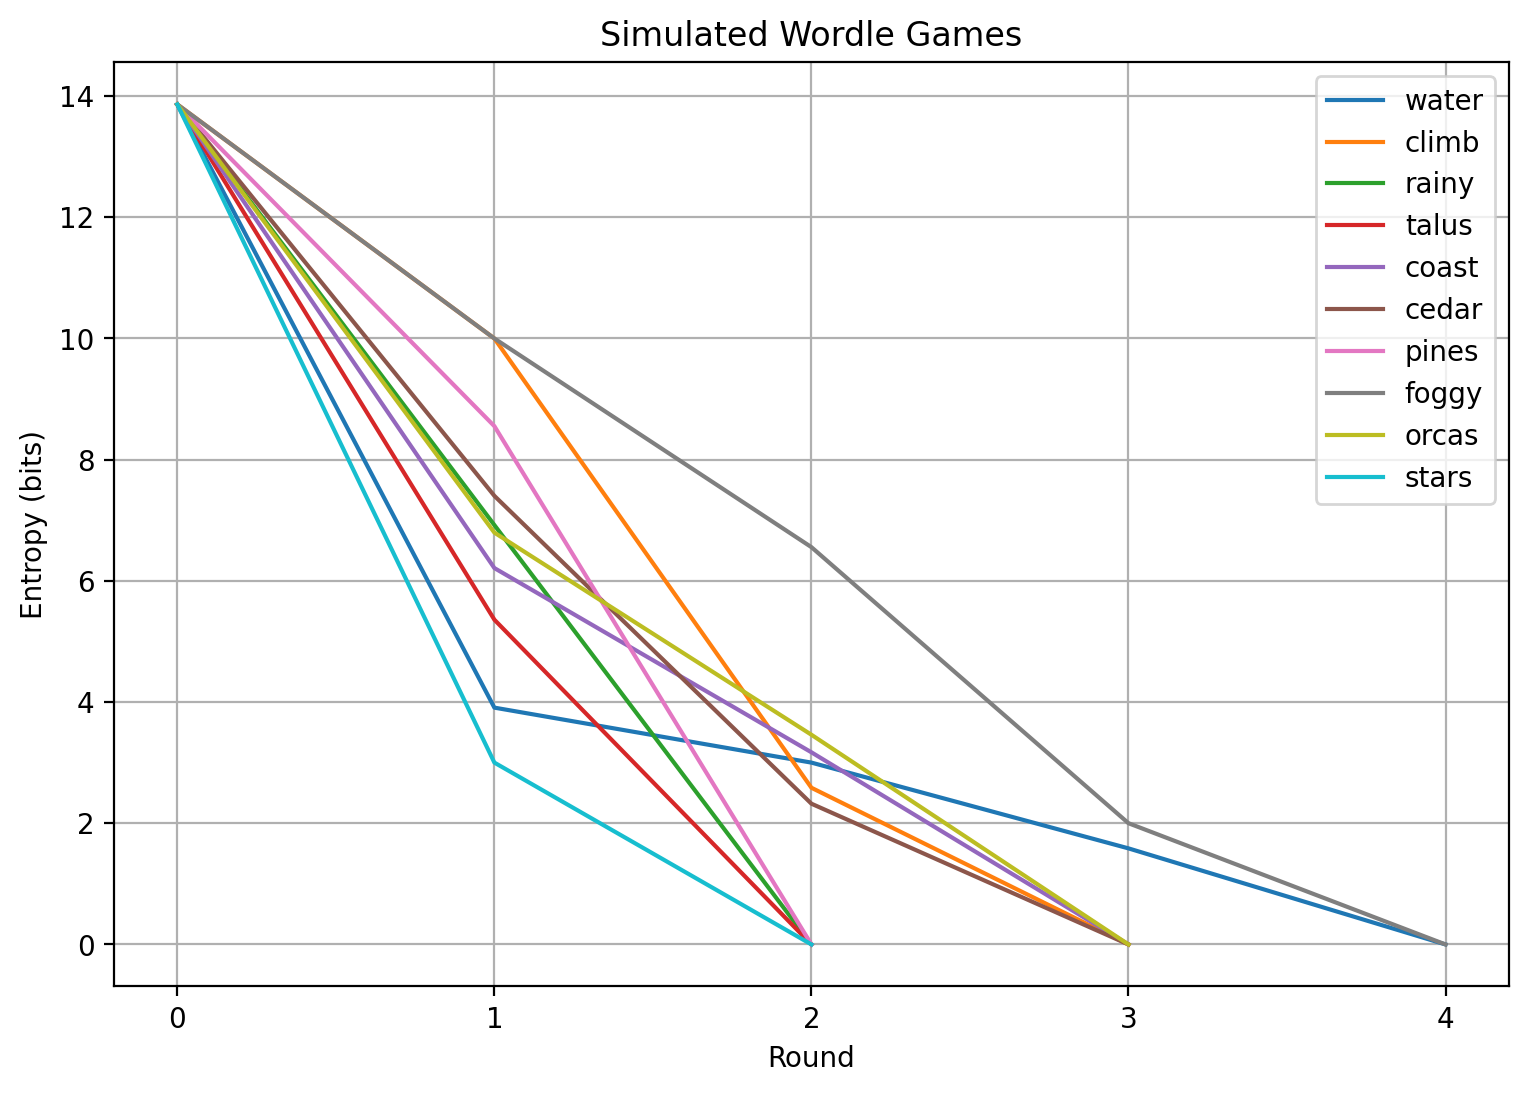

In [3]:
import numpy as np
from matplotlib import pyplot as plt

max_guesses = max(len(sol) for sol in history.values())

plt.figure(figsize=(9, 6), dpi=200)
plt.title(f'Simulated Wordle Games')
plt.xlabel('Round')
plt.ylabel('Entropy (bits)')
plt.grid(True)

for word, entrops in history.items():
    plt.plot(entrops, label=word)

plt.xticks(ticks=np.arange(max_guesses))
plt.legend(loc='best')
plt.show()